# Synthetic Oligo Model Anaylsis - Test PCR Cycles 


## Preprocessing
- Run *RETrace2/scripts/fastq_microsatellite_extractor.py* to extract microsatellite from fastq.gz to get the result.tsv

```bash
#!/bin/bash
for file in /home/tcheng/Projects/RETrace/20220529_MiSeqv2_1ntOligo/0_Raw_Data/Fastq/*.fastq; do
    if [ -f "$file" ]; then
        echo "Processing: $(basename "$file")"
        python /home/tcheng/software/RETrace2/scripts/fastq_microsatellite_extractor.py "$file" ./
        echo "Completed: $(basename "$file")"
        echo "---"
    else
        echo "No .fastq.gz files found in the directory"
    fi
done

echo "All files processed!"
```


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import seaborn as sns
from tqdm import tqdm

In [2]:
path_ls = ['/home/tcheng/Projects/RETrace/20220529_MiSeqv2_1ntOligo/1_Read/1ntOligo_30cycles_20220529_set1_S1_L001_R1_001_result.tsv',
           '/home/tcheng/Projects/RETrace/20220529_MiSeqv2_1ntOligo/1_Read/1ntOligo_35cycles_20220529_set1_S2_L001_R1_001_result.tsv',
           '/home/tcheng/Projects/RETrace/20220529_MiSeqv2_1ntOligo/1_Read/1ntOlgio_40cycles_20220529_set1_S3_L001_R1_001_result.tsv'] 

# groups to compare
fname_ls = ['30cycles', '35cycles', '40cycles'] 

# Stats

## n_read

In [3]:
result_ls = [pd.read_csv(path, sep='\t') for path in path_ls]

In [4]:
# check result df
result_ls[0].head(10)

,read,umi,lib,ms
0,TAACGTGCGTGCTTGTAGATTATCTTATGGAATTGGACACAATACC...,CGTGCGTGCTTGTAGATTAT,CTTATGGAAT,ACACACACACACACACACAC
1,TAATCCAGGGATCTTTTGTGATTATATGAGACGAGCTAAGATTGTA...,TCCAGGGATCTTTTGTGATT,ATATGAGACG,AAAAAAAAAAAAAAAAAAAAAAAAAA
2,TAACTTTTACAGTTTGTCTTGTTATATGAGACGAGCTAAGATTGTA...,CTTTTACAGTTTGTCTTGTT,ATATGAGACG,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA
3,TAAGTATCTGGGGAGTTGTCGTGCGCTCAGTTCGGGGTTCTGCTTT...,GTATCTGGGGAGTTGTCGTG,CGCTCAGTTC,AAAAAAAAAAAAAA
4,TAAGGATTAAATATTTGGAAATAATATGAGACGAGCTAAGATTGTA...,GGATTAAATATTTGGAAATA,ATATGAGACG,AAAAAAAAAAAAAAAAAAAAAAAAAAAAA
5,TAATTGAAGTTCAGATGCAGTTTATATGAGACGAGCTAAGATTGTA...,TTGAAGTTCAGATGCAGTTT,ATATGAGACG,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA
6,TAAATTTGTCTCAGATTTTTCTGCGCTCAGTTCGGGGTTCTGCTTT...,ATTTGTCTCAGATTTTTCTG,CGCTCAGTTC,AAAAAAAAAAAAAAAA
7,TAACAAATGTACTGGCCAGGTGCAGTGGCTCACACCTGTAATCCTA...,CAAATGTACTGGCCAGGTGC,AGTGGCTCAC,NaN
8,TAAGGCACGGAGTGGCCTAGCACATATGAGACGAGCTAAGATTGTA...,GGCACGGAGTGGCCTAGCAC,ATATGAGACG,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA
9,TAACCGTTGGATGTGAGACAGGGTATCTGACCTGATTGTGCCACTG...,CCGTTGGATGTGAGACAGGG,TATCTGACCT,AAAAAAAAAAAAAAAAAAAAA


In [5]:
for i, result in enumerate(result_ls):
    n_total = result.shape[0]
    print(f'{fname_ls[i]}: Total num of reads: {n_total}')

30cycles: Total num of reads: 3215138
35cycles: Total num of reads: 2180301
40cycles: Total num of reads: 3729446


## % total match library index
- Based on olgio synthesis error rate, this should be ~80 to 90%

In [6]:
# check library index count
#result_ls[0]['lib'].value_counts()[:10]

In [7]:
# accurate library index vs ms match
lib_to_ms = {'CGCTCAGTTC': 'AAAAAAAAAAAAAAA', 'TATCTGACCT':'AAAAAAAAAAAAAAAAAAAA', 'ATATGAGACG':'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA',
               'CTTATGGAAT': 'ACACACACACACACACACAC', 'TAATCTCGTC': 'ACACACACACACACACACACACACACACAC'}

In [8]:
# count n pefect match known library index
for i, result in enumerate(result_ls):
    n_match = sum([lib in lib_to_ms.keys() for lib in result['lib']])
    n_total = result.shape[0]
    print(f'{fname_ls[i]}: %matach library index: {round(n_match/n_total*100,2)}%')

30cycles: %matach library index: 89.01%
35cycles: %matach library index: 80.82%
40cycles: %matach library index: 85.35%


## % total match MS sequence (no NA in MS col)
- only a few percentage decrease from % total match library index, indicating most MS sequence can be reg matched

In [9]:
for i, result in enumerate(result_ls):
    n_na = sum(result['ms'].isna())
    n_total = result.shape[0]
    print(f'{fname_ls[i]}: %match MS sequence: {round((n_total-n_na)/n_total*100,2)}%')

30cycles: %match MS sequence: 86.94%
35cycles: %match MS sequence: 78.7%
40cycles: %match MS sequence: 82.66%


## Depth coverage distribution
- This is to see if sequencing is deep enough, we want most >10 depth

In [10]:
# rough check %umi > 10 depth, that is our criteria for evaluating accuracy, but there are some overlap umi between libraries
thres = 10
n_high_ls =[]
n_high_perc_ls = []

for i, result in enumerate(result_ls):
    umi_count = result['umi'].value_counts()
    n_high = sum(umi_count >= thres)
    n_high_perc = round(n_high/len(umi_count)*100, 2)
    
    n_high_ls.append(n_high)
    n_high_perc_ls.append(n_high_perc)
    
    print(f'{fname_ls[i]}: Num of umi >= {thres} depth: {n_high} ({n_high_perc}%)')

30cycles: Num of umi >= 10 depth: 48022 (48.29%)
35cycles: Num of umi >= 10 depth: 48202 (53.32%)
40cycles: Num of umi >= 10 depth: 48983 (42.48%)


/tmp/ipykernel_319785/2445333278.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10').colors


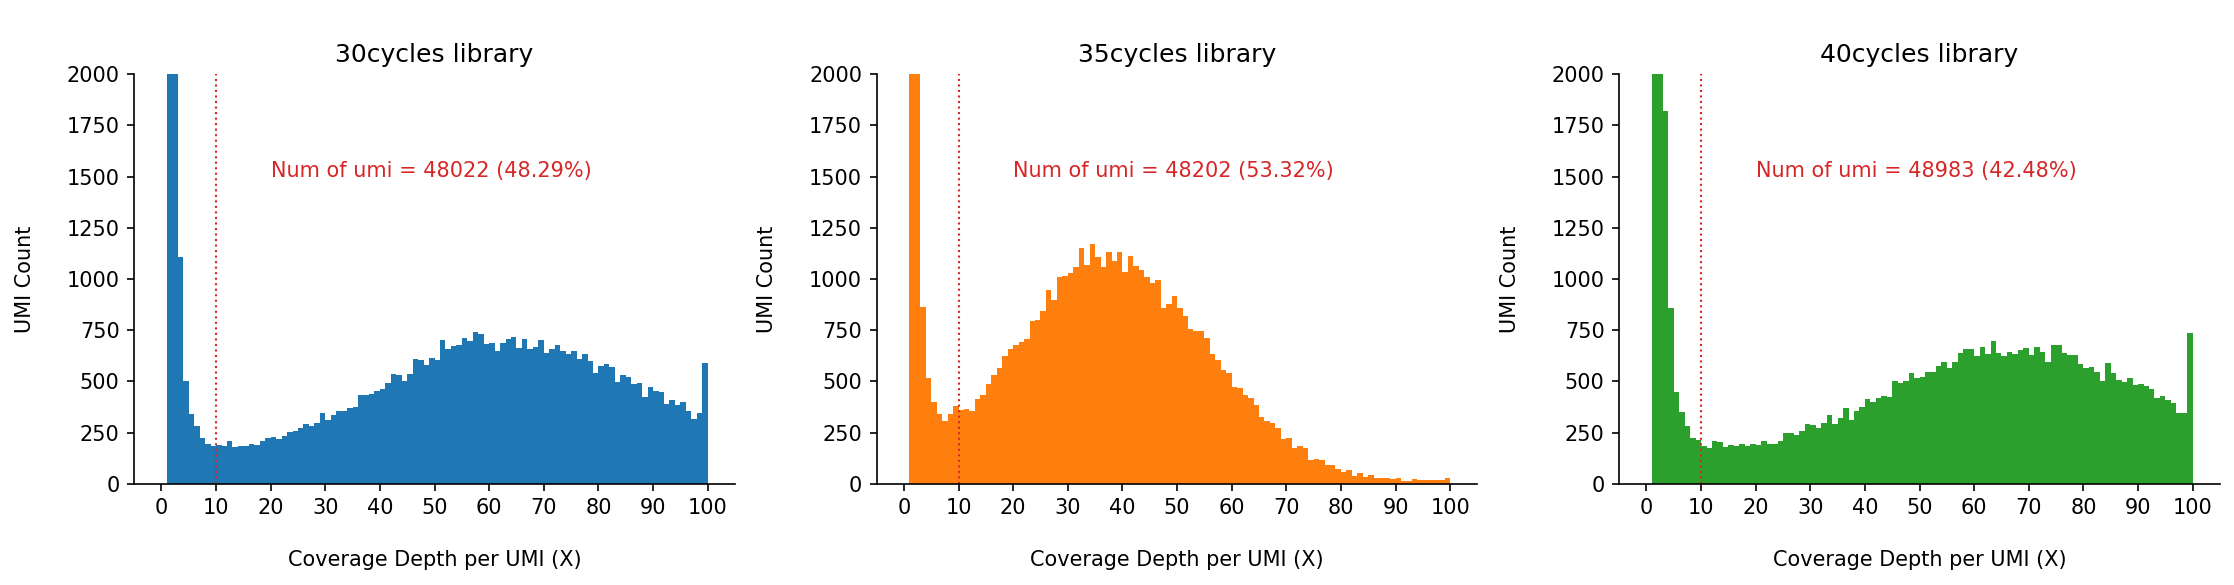

In [11]:
cmap = cm.get_cmap('tab10').colors
n= len(result_ls)
fig, ax = plt.subplots(figsize=(5*n,4), dpi=150, ncols=n)

for i, result in enumerate(result_ls):
    ax[i].hist(result['umi'].value_counts(), bins=100, range=(0,100), color=cmap[i])
    
    ax[i].set_xticks(np.arange(0,101,10))
    ax[i].set_title(f'\n{fname_ls[i]} library')
    ax[i].set_xlabel("\nCoverage Depth per UMI (X)")
    ax[i].set_ylabel("UMI Count\n")

    ax[i].spines['right'].set_visible(False)
    ax[i].spines['top'].set_visible(False)

# note: set ymax bc too high distribution at <5
for i, ax in enumerate(ax):
    ax.set_ylim(0,2000)
    ax.axvline(10, c='tab:red', ls='dotted', linewidth=1)
    ax.text(20, 1500, f'Num of umi = {n_high_ls[i]} ({n_high_perc_ls[i]}%)', c='tab:red')
    
plt.tight_layout()
plt.show()

- 35 cycles look more deviated to left bc there are less reads!

# Oligo design perfect match with read seq
- this is usally ~30% (70% error is from oligo synthesis + pcr + sequencing error)

In [12]:
# filter library index, ms seq, 
filter_dc = {}
for i, result in enumerate(result_ls):
    
    # filter df with lib matches
    is_match = [lib in lib_to_ms.keys() for lib in result['lib']]
    filter_df = result.iloc[is_match,]
    
    # remove na in ms col, these are ones with library index match, but cannot find ms sequence
    filter_df = filter_df.dropna(subset=['ms'])
 
    filter_dc[fname_ls[i]] = filter_df

In [13]:
for lib, filter_df in filter_dc.items():
    # match
    match_ls = filter_df['lib'].map(lib_to_ms) == filter_df['ms']

    # percebt of perfect match (design oligo vs read seq)
    print(f'{lib}: %read with oligo design match ms seq: {round(sum(match_ls)/len(match_ls)*100,2)}%')  

30cycles: %read with oligo design match ms seq: 31.62%
35cycles: %read with oligo design match ms seq: 29.94%
40cycles: %read with oligo design match ms seq: 27.69%


# Find most freqent n_repeat (mode)
- we will assume this is initial oligo sequence

In [14]:
# find min num of read among three library, normalize to this (not sure if sample size matters, just being careful...)
min_read = min([filter_df.shape[0] for lib, filter_df in filter_dc.items()])
min_read

1715811

In [15]:
random_state = 1 
# combine 3 library into 1 df, downsample read, add n_cycle col
filter_df_ls =[]
for lib, filter_df in filter_dc.items():
    filter_df = filter_df.sample(n=min_read, random_state=random_state)
    filter_df['n_cycles'] = lib
    filter_df_ls.append(filter_df)

comb_df = pd.concat(filter_df_ls, ignore_index=True)  #ignore_index to reset index --> or get 3 replicate same index


In [16]:
# add library name from lib lindex
lib_to_name = {'CGCTCAGTTC': '15xA', 'TATCTGACCT':'20xA', 'ATATGAGACG':'30xA', 'CTTATGGAAT': '10xAC', 'TAATCTCGTC': '15xAC'}
comb_df['lib_name'] = [lib_to_name[lib] for lib in comb_df['lib']]

In [17]:
# combine cols for easier grouping, and bc umi can overlap between libraries
comb_df['umi_ncycles_libname'] = [f'{comb_df.umi[i]}_{comb_df.n_cycles[i]}_{comb_df.lib_name[i]}' for i in tqdm(range(comb_df.shape[0]))]

100%|██████████| 5147433/5147433 [01:26<00:00, 59615.60it/s]


In [18]:
# filter only include umi > 10 reads for analysis, use umi+lib+cycles bc some umi overlap...
thres = 10
umi_count = comb_df['umi_ncycles_libname'].value_counts() 
umi_high = umi_count.index[umi_count >= thres]

comb_df = comb_df[[x in umi_high for x in comb_df['umi_ncycles_libname']]]

In [19]:
comb_df['len_ms'] = [len(ms) for ms in comb_df['ms']]

In [20]:
# extract top 1 most frequent repeat, assume this is initial oligo seq
umi_mode_sr = comb_df.groupby(by='umi_ncycles_libname')['len_ms'].agg(lambda x:x.value_counts().index[0])  
umi_to_mode = pd.DataFrame({'umi_ncycles_libname': umi_mode_sr.index, 'mode_len_ms': umi_mode_sr.values})
comb_df = pd.merge(comb_df, umi_to_mode, on='umi_ncycles_libname')

In [21]:
comb_df['nbase_to_mode'] = comb_df.len_ms - comb_df.mode_len_ms

In [22]:
comb_df.head(10)

,read,umi,lib,ms,n_cycles,lib_name,umi_ncycles_libname,len_ms,mode_len_ms,nbase_to_mode
0,TAATTCCCTTATTTCGTTTTTTTCTTATGGAATTGGACACAATACC...,TTCCCTTATTTCGTTTTTTT,CTTATGGAAT,ACACACACACACACACACAC,30cycles,10xAC,TTCCCTTATTTCGTTTTTTT_30cycles_10xAC,20,20,0
1,TAATATCCGTTTCTGGTGTGGGCATATGAGACGAGCTAAGATTGTA...,TATCCGTTTCTGGTGTGGGC,ATATGAGACG,AAAAAAAAAAAAAAAAAAAAAAA,30cycles,30xA,TATCCGTTTCTGGTGTGGGC_30cycles_30xA,23,33,-10
2,TAAATTTAGGTCGGCAAGGACTGTATCTGACCTGATTGTGCCACTG...,ATTTAGGTCGGCAAGGACTG,TATCTGACCT,AAAAAAAAAAAAAAAAAAAAA,30cycles,20xA,ATTTAGGTCGGCAAGGACTG_30cycles_20xA,21,20,1
3,TAAGCAACTAATTTTCGGTAAGATATCTGACCTGATTGTGCCACTG...,GCAACTAATTTTCGGTAAGA,TATCTGACCT,AAAAAAAAAAAAAA,30cycles,20xA,GCAACTAATTTTCGGTAAGA_30cycles_20xA,14,22,-8
4,TAAATAATGCTAAGAGAAGGACGTATCTGACCTGATTGTGCCACTG...,ATAATGCTAAGAGAAGGACG,TATCTGACCT,AAAAAAAAAAAAAAAAAAAA,30cycles,20xA,ATAATGCTAAGAGAAGGACG_30cycles_20xA,20,18,2
5,TAACTGGCTCGGTTTTCTTTTGATAATCTCGTCAAGTGACAGCTAT...,CTGGCTCGGTTTTCTTTTGA,TAATCTCGTC,ACACACACACACACACACACACACACAC,30cycles,15xAC,CTGGCTCGGTTTTCTTTTGA_30cycles_15xAC,28,28,0
6,TAATTGGCGGTAGAGAAAGCGTGATATGAGACGAGCTAAGATTGTA...,TTGGCGGTAGAGAAAGCGTG,ATATGAGACG,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA,30cycles,30xA,TTGGCGGTAGAGAAAGCGTG_30cycles_30xA,31,31,0
7,TAATATGATAGCCGACGGTGAATTATCTGACCTGATTGTGCCACTG...,TATGATAGCCGACGGTGAAT,TATCTGACCT,AAAAAAAAAAAAAAAAA,30cycles,20xA,TATGATAGCCGACGGTGAAT_30cycles_20xA,17,19,-2
8,TAATTTGAGTCGCCTGACTCGAGTAATCTCGTCAAGTGACAGCTAT...,TTTGAGTCGCCTGACTCGAG,TAATCTCGTC,ACACACACACACACACACACACACACACAC,30cycles,15xAC,TTTGAGTCGCCTGACTCGAG_30cycles_15xAC,30,30,0
9,TAAACGGTCTGGTAGCTATCATTTATCTGACCTGATTGTGCCACTG...,ACGGTCTGGTAGCTATCATT,TATCTGACCT,AAAAAAAAAAAAAAAAAAAAAA,30cycles,20xA,ACGGTCTGGTAGCTATCATT_30cycles_20xA,22,18,4


## Add ms_type (1nt vs 2nt)

In [23]:
ms_type = []
for lib in comb_df['lib']:
    if lib in ['CGCTCAGTTC', 'TATCTGACCT', 'ATATGAGACG']:
        ms_type.append(1) # 1nt repeat
        
    elif lib in ['CTTATGGAAT', 'TAATCTCGTC']:
        ms_type.append(2) # 2nt repeat
        
    else:
        print('no match library index!!!check!')
        break
        

In [24]:
comb_df['ms_type'] = ms_type

## Add n repeat to mode

In [25]:
comb_df['nrepeat_to_mode'] = (comb_df['nbase_to_mode']/comb_df['ms_type']).astype(int)

## Save comb_df

In [26]:
comb_df.to_csv('./comb_df.tsv', sep='\t', index=False)

# Plot dispersion, n_repeat from mode

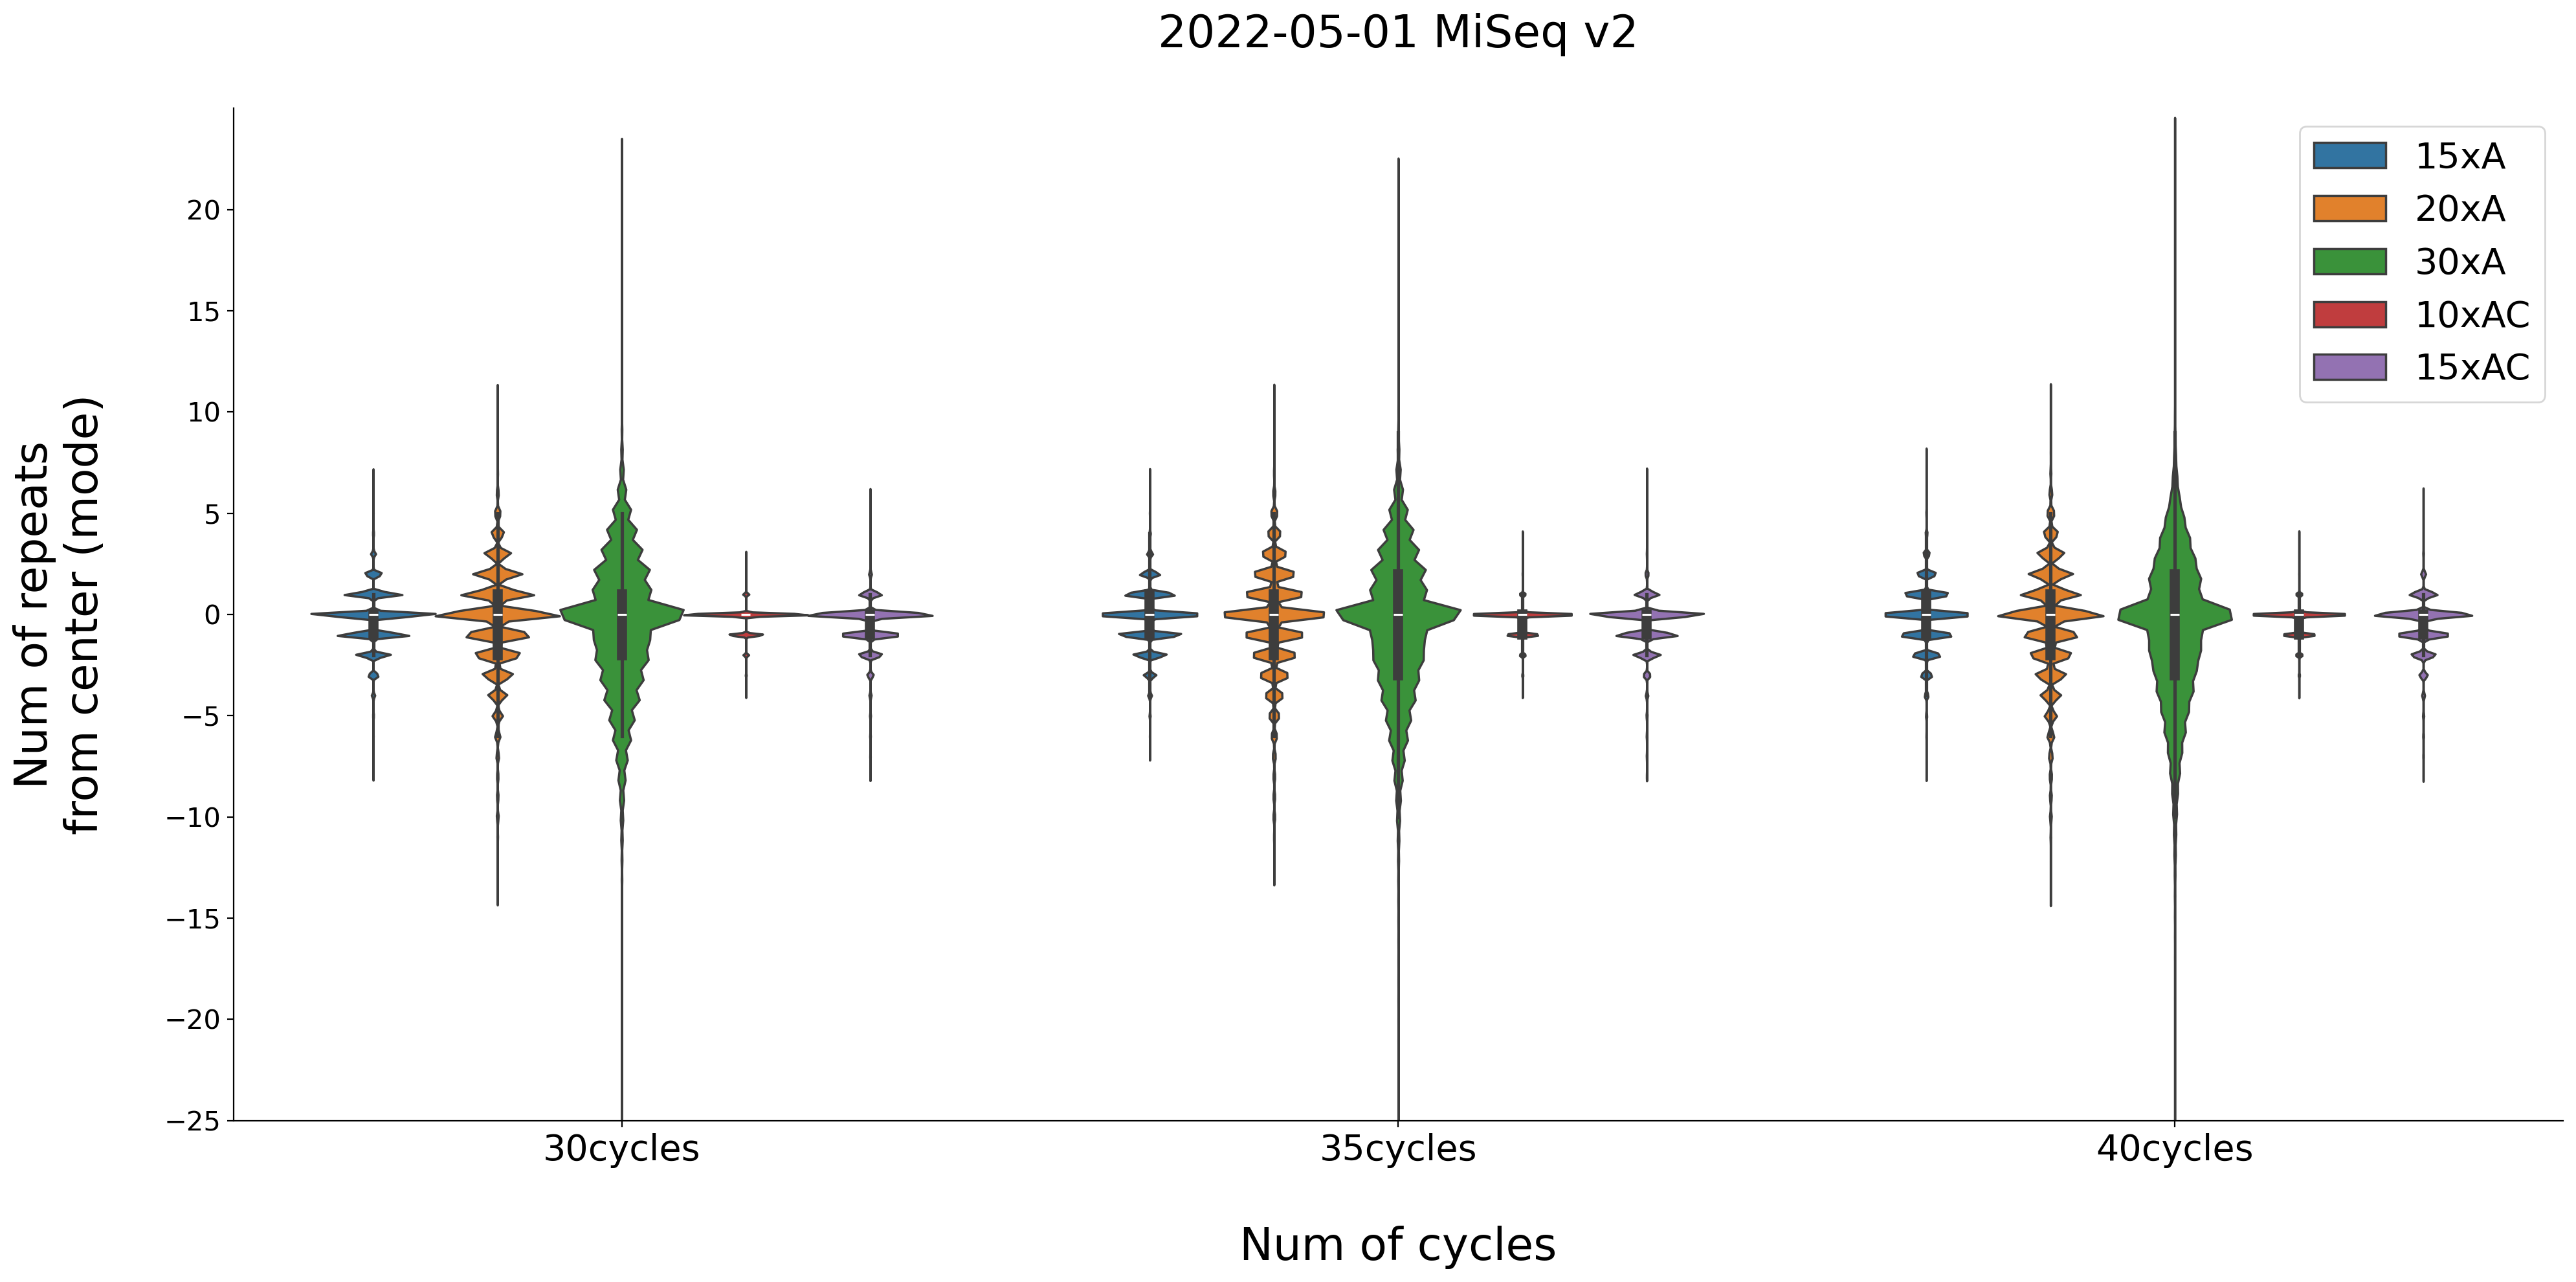

In [27]:
fig, ax = plt.subplots(figsize=(20,10), dpi=200)

sns.violinplot(x='n_cycles', y='nrepeat_to_mode', data=comb_df, hue='lib_name', order=['30cycles', '35cycles', '40cycles'],
               hue_order=['15xA', '20xA', '30xA', '10xAC', '15xAC'])
#sns.stripplot(x='n_cycles', y='nrepeat_to_mode', data=comb_df, hue='lib_name', color='black', size=3, dodge=True,
#               order=['30cycles', '35cycles', '40cycles'], hue_order=['15xA', '20xA', '30xA', '10xAC', '15xAC'])

ax.set_title('2022-05-01 MiSeq v2\n', fontsize=25)
ax.set_xlabel("\nNum of cycles", fontsize=25)
ax.set_ylabel('Num of repeats\nfrom center (mode)\n', fontsize=25)
ax.tick_params(axis='both', labelsize=15)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_ylim(-25,25)
ax.set_yticks(np.arange(-25,25,5))
ax.tick_params(axis='x', which='major', labelsize=20)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:5], labels[:5], fontsize=20, loc='upper right')

plt.tight_layout()
plt.show()

# Check how much umi mode match oligo design
- this is a sanity check, ideally should be 80-90% based on olgio synthesis error, but looks like only ~50%, meaning other variables at play
- for example, sequencing error or early pcr error + amplification bias made them mode


In [28]:
# remove duplicate read, just analyze at umi level
comb_df_mode = comb_df[['umi', 'lib_name', 'mode_len_ms', 'ms_type', 'n_cycles']]
comb_df_mode = comb_df_mode.drop_duplicates()
comb_df_mode = comb_df_mode.reset_index(drop=True)

In [29]:
# split by ncycles
gb = comb_df_mode.groupby('n_cycles')
comb_df_mode_ls = [gb.get_group(x).reset_index(drop=True) for x in gb.groups]

In [30]:
# this check how much library oligo design match our oligo mode
for i, comb_df_mode in enumerate(comb_df_mode_ls):
    match_perc = sum([int(comb_df_mode.lib_name[i][:2])*comb_df_mode.ms_type[i] for i in range(comb_df_mode.shape[0])] == comb_df_mode.mode_len_ms)/comb_df_mode.shape[0]
    print(f'{fname_ls[i]}: umi mode match oligo design: {round(match_perc*100, 2)}%')

30cycles: umi mode match oligo design: 55.8%
35cycles: umi mode match oligo design: 52.06%
40cycles: umi mode match oligo design: 48.0%


# Calculate Accuracy per umi

## Look at one umi for example

In [31]:
comb_df['umi'].value_counts()

umi
CAAATAATACTTTCTACTAA    135
GTTGTCAACAGAGTTGTGGA    132
AGGTAGTTGCGCTCGTATGG    130
GGAGATGGGGCAGTTTTTGT    122
CATGTCATCTTAATGGTATG    118
                       ... 
GTTCCGTACGTAGACTATAC     10
CCCAGATGTTATGTTTAATT     10
AACGTGCGAAGCCAGATCGA     10
GAATCTGTCTTCTTATCCAA     10
ATAGGCAGGATTAGGGAGTT     10
Name: count, Length: 129058, dtype: int64

In [32]:
umi_id = 'CAAATAATACTTTCTACTAA'

In [33]:
counts = comb_df.len_ms[comb_df.umi == umi_id].value_counts()
counts

len_ms
15    46
14    36
13    25
16    10
12     7
17     5
11     3
10     2
20     1
Name: count, dtype: int64

In [34]:
sum(counts)

135

In [35]:
counts.iloc[0]/sum(counts)

0.34074074074074073

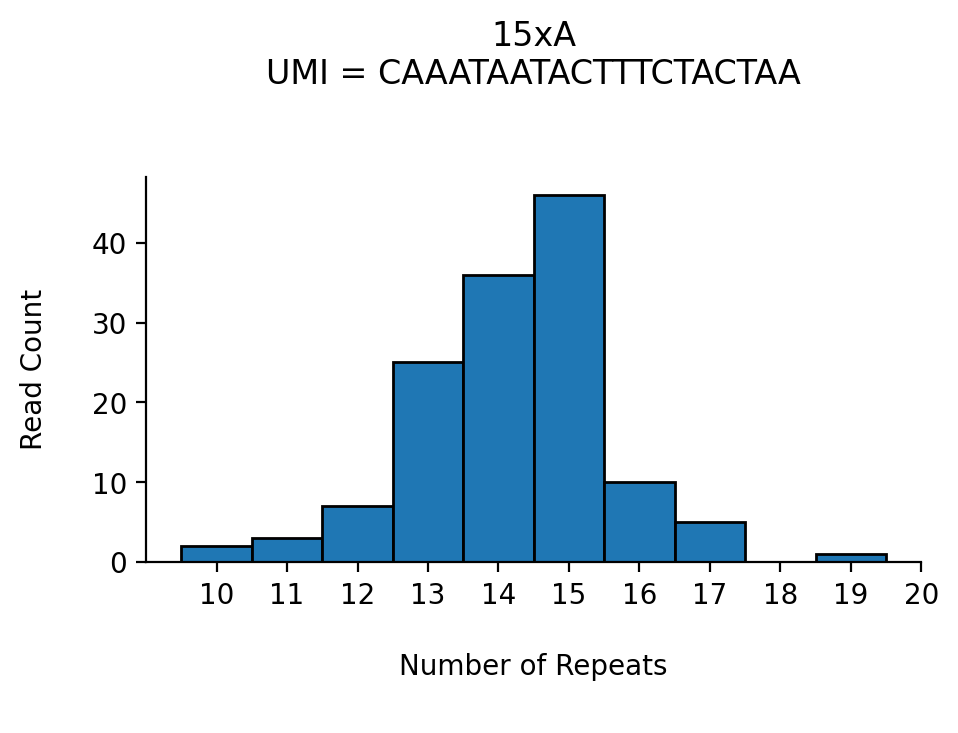

In [36]:
n_repeat = 15
motif = 'A'

fig, ax = plt.subplots(figsize=(5,2.5), dpi=200)
plt.hist(comb_df.len_ms[comb_df.umi == umi_id], np.arange(n_repeat-5,n_repeat+6), edgecolor='black', color='tab:blue')

ax.set_title(f'{n_repeat}x{motif}\nUMI = {umi_id}\n\n')#, fontsize=10)
ax.set_ylabel('Read Count\n')
ax.set_xlabel('\nNumber of Repeats\n')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# work around to set n_repeat to center of tick
ax.set_xticks(np.arange(n_repeat-5+0.5,n_repeat+6+0.5))
ax.set_xticklabels(np.arange(n_repeat-5,n_repeat+6))
#ax.set_yticks(np.arange(0,11,2))

plt.show()

In [37]:
comb_df.query('ms_type == 2').umi.value_counts()[:10]

umi
TTGTAGATATACGATTTTAT    104
AGGAGTGTTTCATGGTTAGT     98
GTTGATTTAATGTACAGACA     96
GATGCGTTTGACACTTTAGG     95
TTCACGGGACGTCCCTATTC     94
GAGAGAGTTCTAACCCCGAC     93
TCGGCATCCGTCTACGCGCG     92
GTTTAACAATATTGAGACGG     92
GCAGTCAGCGTAGAGACCGC     92
GTACTTAATGAGAGAGGTAC     91
Name: count, dtype: int64

In [38]:
umi_id = 'AAATTTCCGGCGCACCAGGT'

In [39]:
counts = comb_df.len_ms[comb_df.umi == umi_id].value_counts()
counts

len_ms
30    32
28    18
26    13
32     3
24     2
16     1
22     1
Name: count, dtype: int64

In [40]:
counts.iloc[0]/sum(counts)

0.45714285714285713

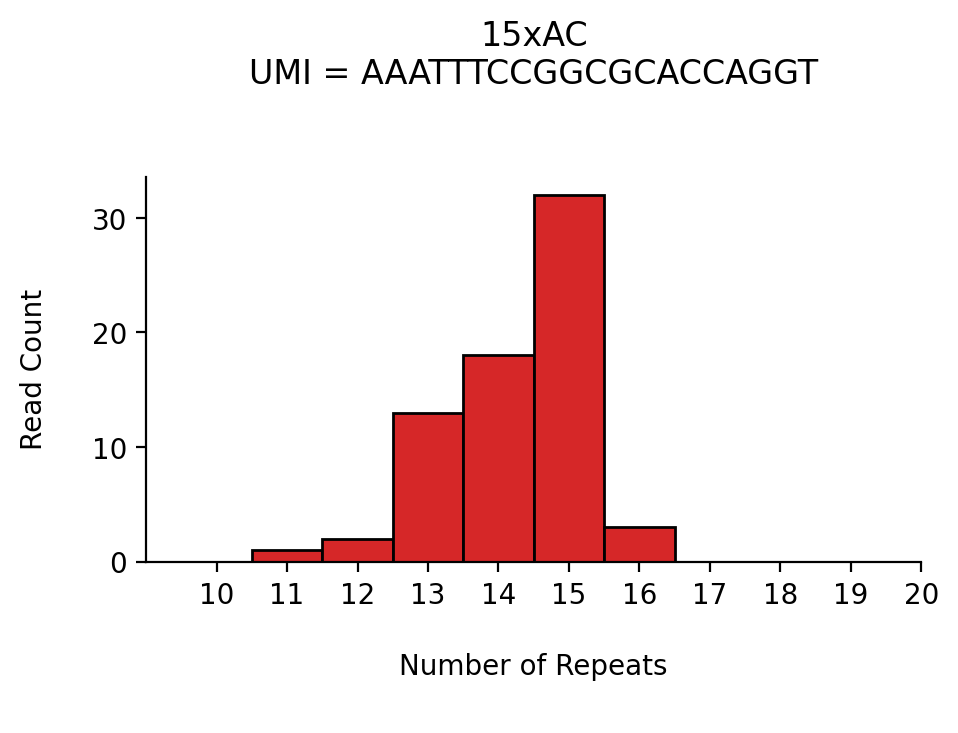

In [41]:
n_repeat = 15
motif = 'AC'


fig, ax = plt.subplots(figsize=(5,2.5), dpi=200)
plt.hist(comb_df.len_ms[comb_df.umi == umi_id]/len(motif), np.arange(n_repeat-5,n_repeat+6), edgecolor='black', color='tab:red')

ax.set_title(f'{n_repeat}x{motif}\nUMI = {umi_id}\n\n')#, fontsize=10)
ax.set_ylabel('Read Count\n')
ax.set_xlabel('\nNumber of Repeats\n')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# work around to set n_repeat to center of tick
ax.set_xticks(np.arange(n_repeat-5+0.5,n_repeat+6+0.5))
ax.set_xticklabels(np.arange(n_repeat-5,n_repeat+6))

plt.show()

## Look at all UMI accuracy

In [42]:
# per umi accuracy, extract n_read with 0 repeat to mode (accurate) / sum  
umi_acc = comb_df.groupby('umi_ncycles_libname')['nrepeat_to_mode'].agg(lambda x: x.value_counts()[0]/sum(x.value_counts())*100)  
umi_acc_df = pd.DataFrame({'umi_ncycles_libname':umi_acc.index, 'umi_accuracy':umi_acc.values})

In [43]:
umi_to_meta = comb_df[['umi_ncycles_libname', 'umi', 'n_cycles', 'lib_name']].drop_duplicates()
umi_acc_df = pd.merge(umi_acc_df, umi_to_meta, on='umi_ncycles_libname')
umi_acc_df

,umi_ncycles_libname,umi_accuracy,umi,n_cycles,lib_name
0,AAAAAACTGGAGCTTTAGGT_35cycles_10xAC,54.901961,AAAAAACTGGAGCTTTAGGT,35cycles,10xAC
1,AAAAAAGAAGTAGCTAGTTG_30cycles_30xA,21.052632,AAAAAAGAAGTAGCTAGTTG,30cycles,30xA
2,AAAAAAGATTATCAGTTAAC_30cycles_15xA,38.333333,AAAAAAGATTATCAGTTAAC,30cycles,15xA
3,AAAAAAGCTAACGCTCATTG_35cycles_15xAC,43.636364,AAAAAAGCTAACGCTCATTG,35cycles,15xAC
4,AAAAAAGGACCCTTTTATTG_35cycles_10xAC,75.675676,AAAAAAGGACCCTTTTATTG,35cycles,10xAC
...,...,...,...,...,...
129053,TTTTTTTTGGTAATTACTTG_30cycles_15xA,32.692308,TTTTTTTTGGTAATTACTTG,30cycles,15xA
129054,TTTTTTTTGTAAAAAAGAGA_30cycles_15xA,26.666667,TTTTTTTTGTAAAAAAGAGA,30cycles,15xA
129055,TTTTTTTTTGTTAAACTTTA_40cycles_15xA,46.666667,TTTTTTTTTGTTAAACTTTA,40cycles,15xA
129056,TTTTTTTTTTCGTAAGTGAA_35cycles_20xA,22.857143,TTTTTTTTTTCGTAAGTGAA,35cycles,20xA


## Stats

In [44]:
umi_acc_df.groupby(['n_cycles', 'lib_name']).describe()

umi_accuracy                                              \
                         count       mean        std        min        25%   
n_cycles lib_name                                                            
30cycles 10xAC          3212.0  73.528043   9.622738  33.898305  68.323171   
         15xA          11256.0  39.030412   7.091049  19.565217  34.042553   
         15xAC          2927.0  51.565223   9.180346  21.666667  45.098039   
         20xA          13129.0  26.713925   5.791158  13.333333  22.727273   
         30xA          12175.0  22.186410   5.395275   9.523810  18.421053   
35cycles 10xAC          3362.0  70.501123   9.660737  33.333333  64.912281   
         15xA          11133.0  37.047195   6.631518  18.750000  32.352941   
         15xAC          2885.0  47.853912   8.700388  22.500000  41.666667   
         20xA          13611.0  25.664273   5.609287  13.157895  21.739130   
         30xA          12177.0  21.953570   5.479360  10.000000  18.181818   
40cycles 10xAC          3425.0  68.083482  10.334680  33.333333  61.666667   
         15xA          11302.0  35.628479   6.862818  17.857143  30.882353   
         15xAC          2825.0  44.712402   8.393773  22.727273  38.709677   
         20xA          13360.0  24.674661   5.607598  11.111111  20.754717   
         30xA          12279.0  21.301339   5.296897  10.416667  17.647059   

                                                     
                         50%        75%         max  
n_cycles lib_name                                    
30cycles 10xAC     74.615020  80.000000  100.000000  
         15xA      38.461538  43.181818  100.000000  
         15xAC     51.351351  57.446809  100.000000  
         20xA      25.925926  29.729730   78.947368  
         30xA      21.428571  25.000000   83.636364  
35cycles 10xAC     71.428571  76.923077  100.000000  
         15xA      36.363636  40.909091   81.818182  
         15xAC     47.368421  53.061224   97.222222  
         20xA      25.000000  28.571429   86.363636  
         30xA      21.052632  25.000000   94.736842  
40cycles 10xAC     68.750000  75.000000  100.000000  
         15xA      34.883721  39.473684   93.023256  
         15xAC     44.000000  50.000000   91.891892  
         20xA      23.809524  27.586207   97.916667  
         30xA      20.338983  24.000000   85.000000

In [45]:
umi_acc_df.groupby(['lib_name', 'n_cycles']).describe().reindex([('15xA','30cycles'), ('15xA','35cycles'), ('15xA','40cycles'),
                                                                 ('20xA','30cycles'), ('20xA','35cycles'), ('20xA','40cycles'),
                                                                 ('30xA','30cycles'), ('30xA','35cycles'), ('30xA','40cycles'),
                                                                 ('10xAC','30cycles'), ('10xAC','35cycles'), ('10xAC','40cycles'),
                                                                 ('15xAC','30cycles'), ('15xAC','35cycles'), ('15xAC','40cycles')])


umi_accuracy                                              \
                         count       mean        std        min        25%   
lib_name n_cycles                                                            
15xA     30cycles      11256.0  39.030412   7.091049  19.565217  34.042553   
         35cycles      11133.0  37.047195   6.631518  18.750000  32.352941   
         40cycles      11302.0  35.628479   6.862818  17.857143  30.882353   
20xA     30cycles      13129.0  26.713925   5.791158  13.333333  22.727273   
         35cycles      13611.0  25.664273   5.609287  13.157895  21.739130   
         40cycles      13360.0  24.674661   5.607598  11.111111  20.754717   
30xA     30cycles      12175.0  22.186410   5.395275   9.523810  18.421053   
         35cycles      12177.0  21.953570   5.479360  10.000000  18.181818   
         40cycles      12279.0  21.301339   5.296897  10.416667  17.647059   
10xAC    30cycles       3212.0  73.528043   9.622738  33.898305  68.323171   
         35cycles       3362.0  70.501123   9.660737  33.333333  64.912281   
         40cycles       3425.0  68.083482  10.334680  33.333333  61.666667   
15xAC    30cycles       2927.0  51.565223   9.180346  21.666667  45.098039   
         35cycles       2885.0  47.853912   8.700388  22.500000  41.666667   
         40cycles       2825.0  44.712402   8.393773  22.727273  38.709677   

                                                     
                         50%        75%         max  
lib_name n_cycles                                    
15xA     30cycles  38.461538  43.181818  100.000000  
         35cycles  36.363636  40.909091   81.818182  
         40cycles  34.883721  39.473684   93.023256  
20xA     30cycles  25.925926  29.729730   78.947368  
         35cycles  25.000000  28.571429   86.363636  
         40cycles  23.809524  27.586207   97.916667  
30xA     30cycles  21.428571  25.000000   83.636364  
         35cycles  21.052632  25.000000   94.736842  
         40cycles  20.338983  24.000000   85.000000  
10xAC    30cycles  74.615020  80.000000  100.000000  
         35cycles  71.428571  76.923077  100.000000  
         40cycles  68.750000  75.000000  100.000000  
15xAC    30cycles  51.351351  57.446809  100.000000  
         35cycles  47.368421  53.061224   97.222222  
         40cycles  44.000000  50.000000   91.891892

## Plot

/tmp/ipykernel_319785/3026500298.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x='n_cycles', y='umi_accuracy', data=umi_acc_df, hue='lib_name', color='black', size=3, dodge=True,


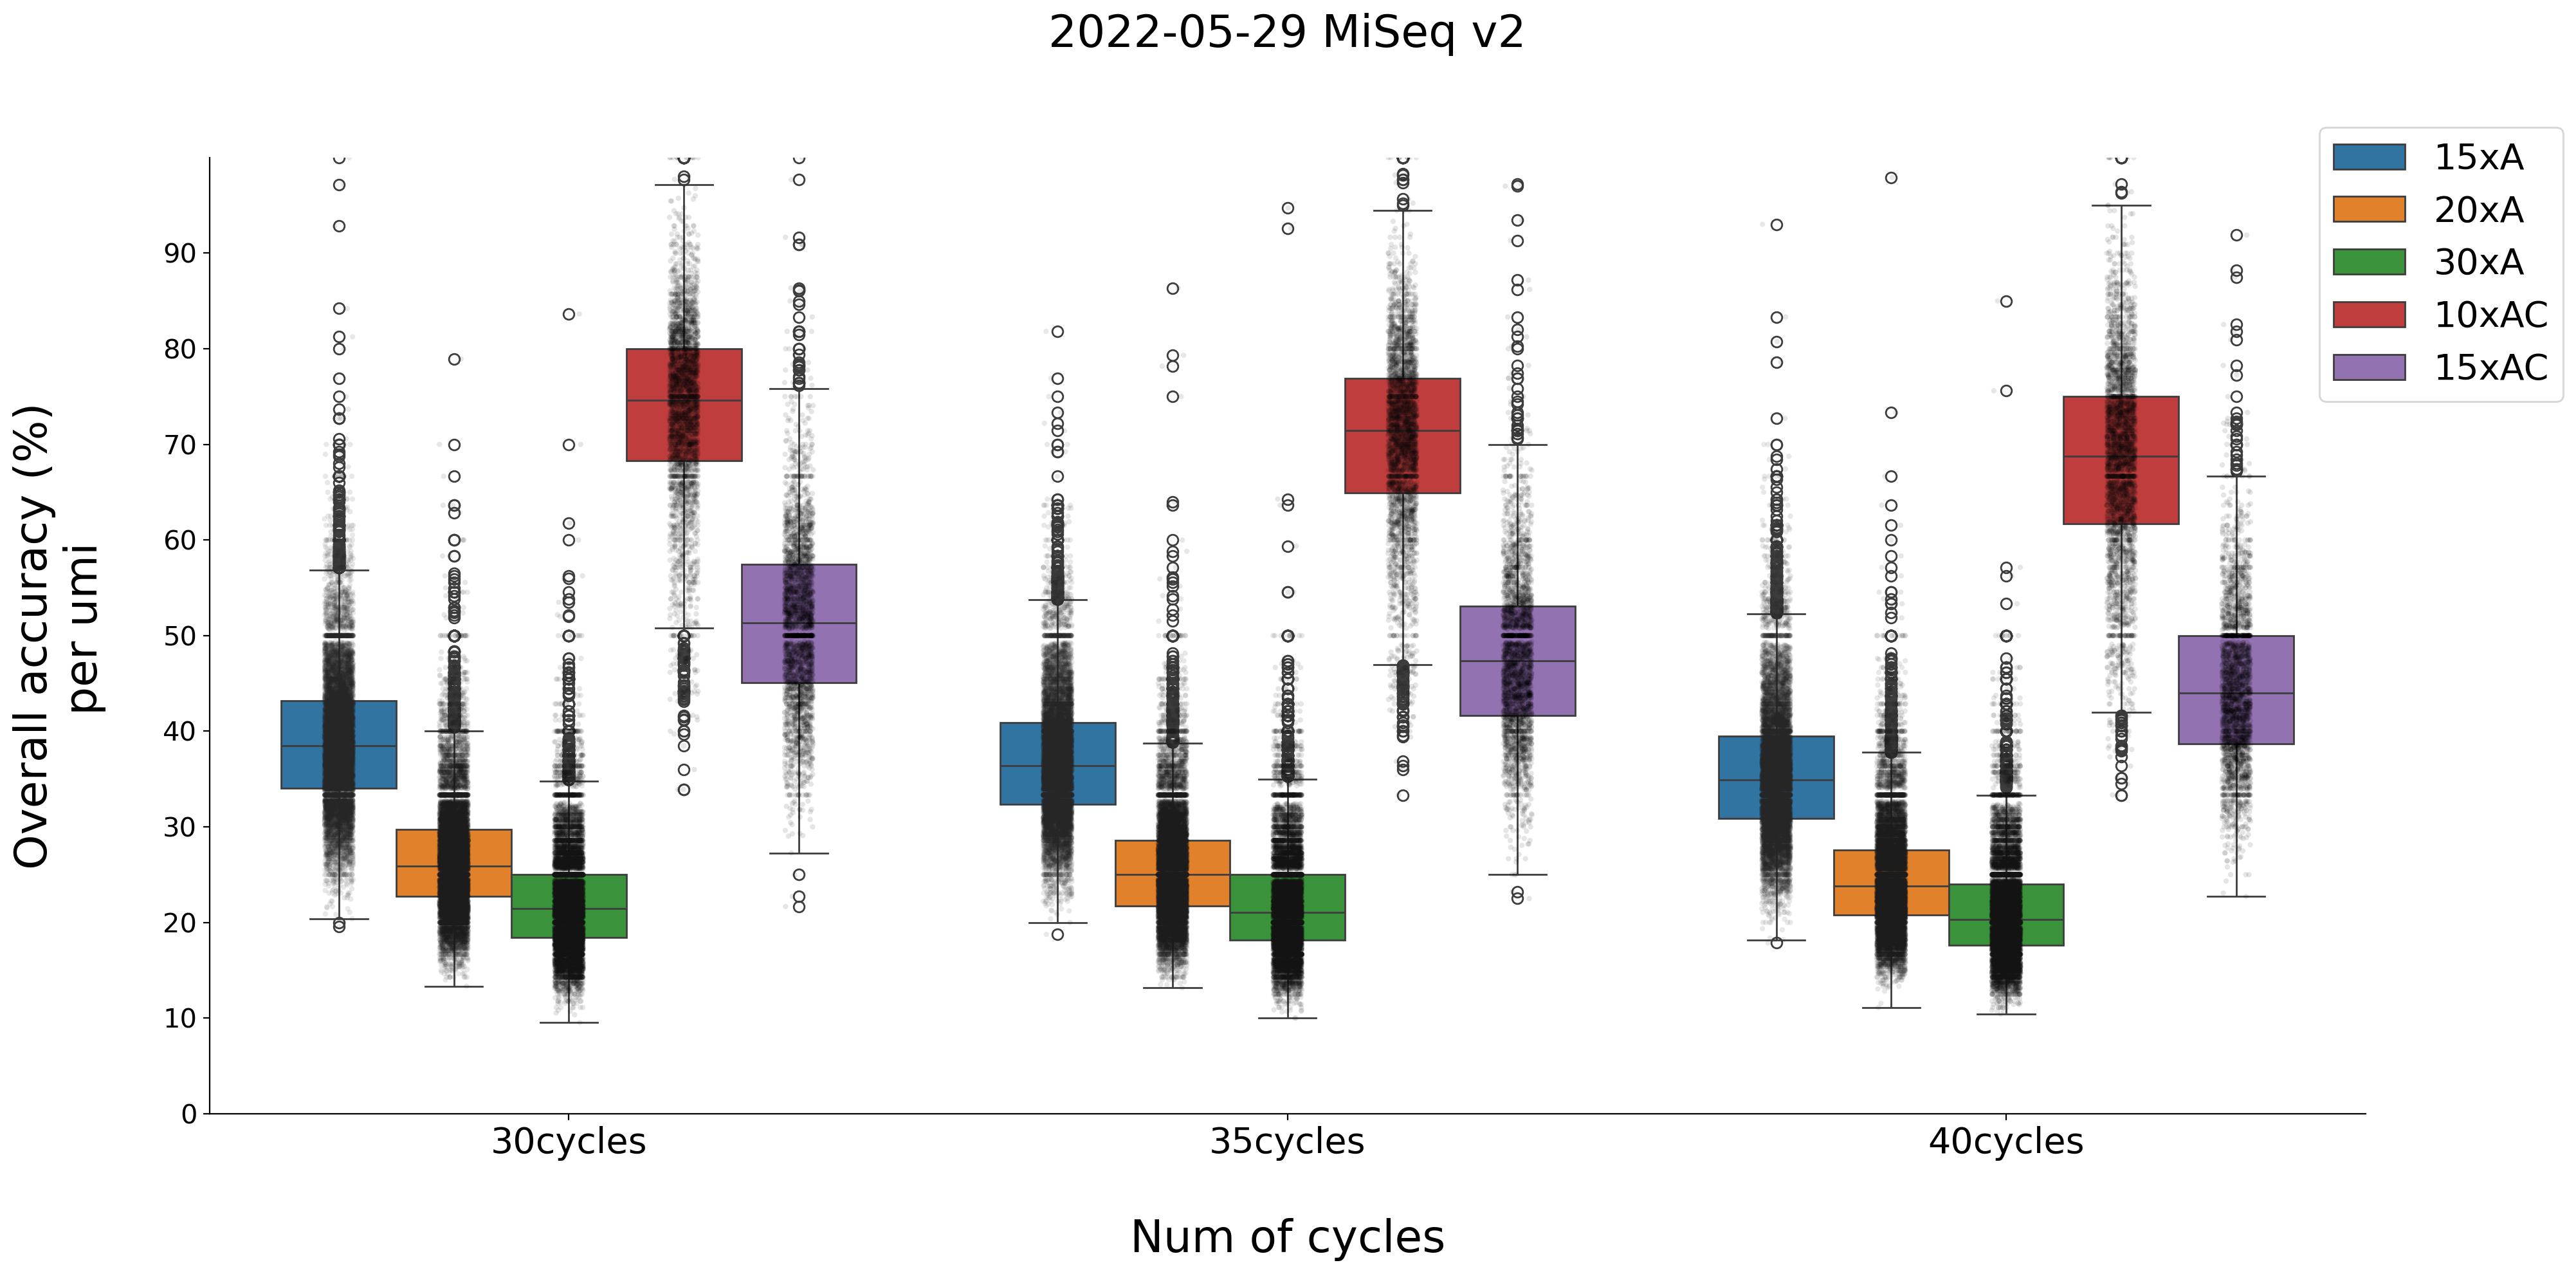

In [46]:
fig, ax = plt.subplots(figsize=(20,10), dpi=200)

sns.boxplot(x='n_cycles', y='umi_accuracy', data=umi_acc_df, hue='lib_name', order=['30cycles', '35cycles', '40cycles'],
               hue_order=['15xA', '20xA', '30xA', '10xAC', '15xAC'])
sns.stripplot(x='n_cycles', y='umi_accuracy', data=umi_acc_df, hue='lib_name', color='black', size=3, dodge=True,
               order=['30cycles', '35cycles', '40cycles'], hue_order=['15xA', '20xA', '30xA', '10xAC', '15xAC'], alpha=0.1)

ax.set_title('2022-05-29 MiSeq v2\n\n', fontsize=25)
ax.set_xlabel("\nNum of cycles", fontsize=25)
ax.set_ylabel('Overall accuracy (%)\n per umi\n', fontsize=25)
ax.tick_params(axis='both', labelsize=15)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_ylim(0,100)
ax.set_yticks(np.arange(0,100,10))
ax.tick_params(axis='x', which='major', labelsize=20)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:5], labels[:5], fontsize=20, loc='upper right', bbox_to_anchor=(1.1, 1.05))

plt.tight_layout()
plt.show()

/tmp/ipykernel_319785/74623232.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x='lib_name', y='umi_accuracy', data=umi_acc_df, hue='n_cycles', color='black', size=3, dodge=True,


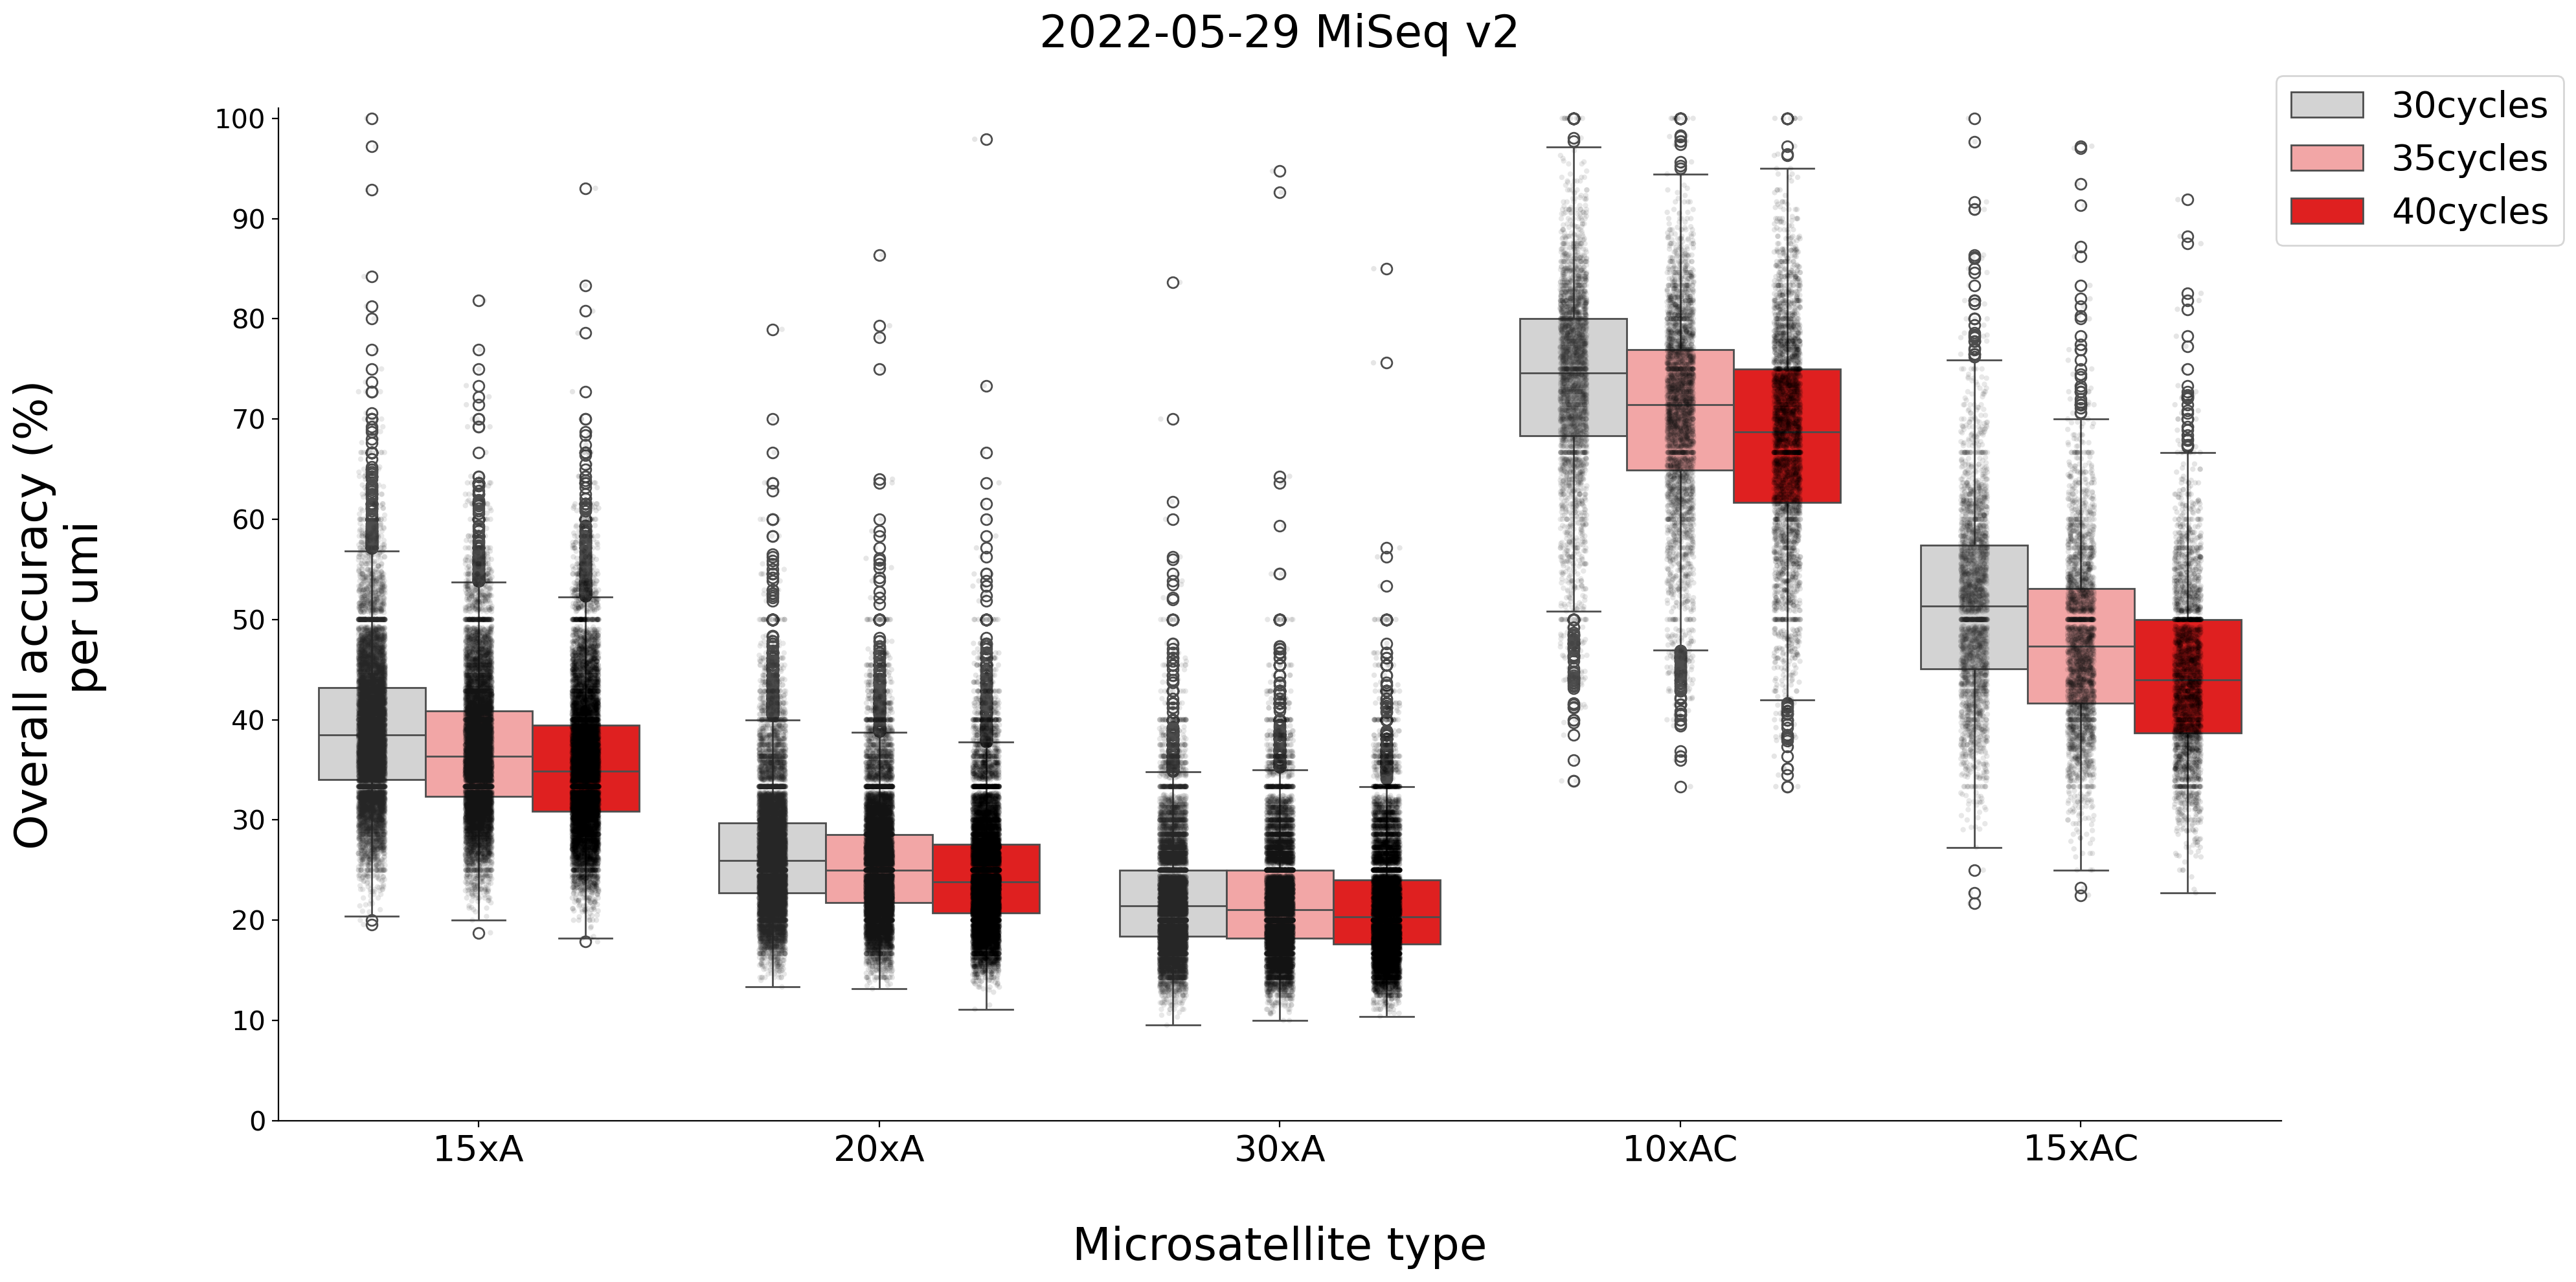

In [47]:
fig, ax = plt.subplots(figsize=(20,10), dpi=200)

sns.boxplot(x='lib_name', y='umi_accuracy', data=umi_acc_df, hue='n_cycles', order=['15xA', '20xA', '30xA', '10xAC', '15xAC'],
               hue_order=['30cycles', '35cycles', '40cycles'], palette=['#D3D3D3', '#FF9999', '#FF0000'])
sns.stripplot(x='lib_name', y='umi_accuracy', data=umi_acc_df, hue='n_cycles', color='black', size=3, dodge=True,
               order=['15xA', '20xA', '30xA', '10xAC', '15xAC'], hue_order=['30cycles', '35cycles', '40cycles'], alpha=0.1)

ax.set_title('2022-05-29 MiSeq v2\n', fontsize=25)
ax.set_xlabel("\nMicrosatellite type", fontsize=25)
ax.set_ylabel('Overall accuracy (%)\n per umi\n\n', fontsize=25)
ax.tick_params(axis='both', labelsize=15)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_ylim(0,101)
ax.set_yticks(np.arange(0,101,10))
ax.tick_params(axis='x', which='major', labelsize=20)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:3], labels[:3], fontsize=20, loc='upper right', bbox_to_anchor=(1.15, 1.05))

plt.tight_layout()
plt.show()

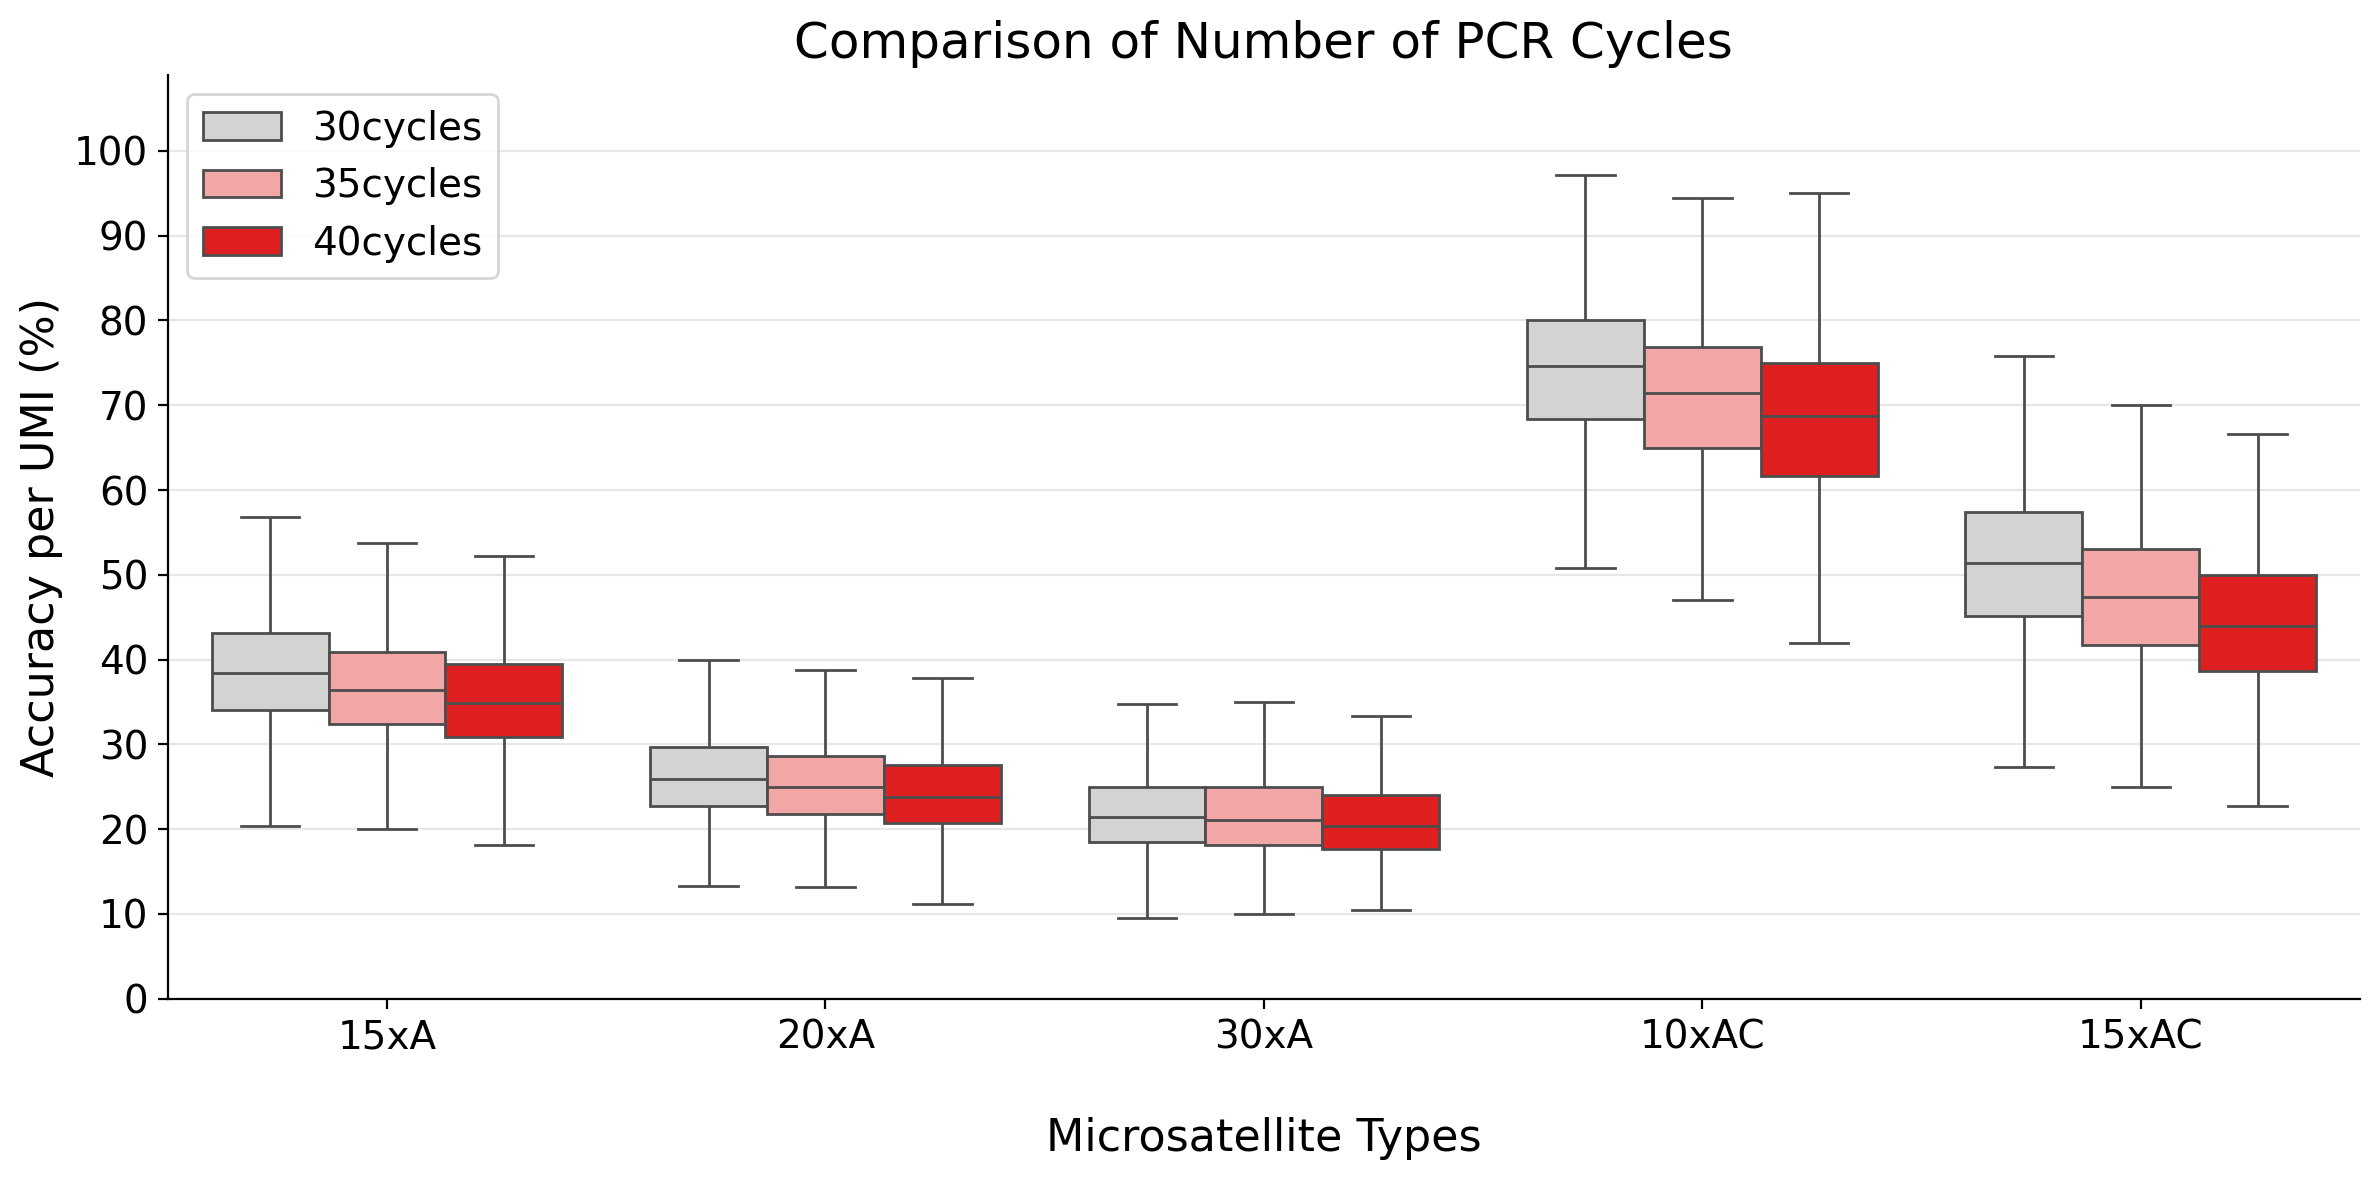

In [ ]:
sns.reset_defaults()
fig, ax = plt.subplots(figsize=(12,6), dpi=200)

sns.boxplot(x='lib_name', y='umi_accuracy', data=umi_acc_df, hue='n_cycles', order=['15xA', '20xA', '30xA', '10xAC', '15xAC'],
               hue_order=['30cycles', '35cycles', '40cycles'], palette=['#D3D3D3', '#FF9999', '#FF0000'], showfliers=False)

ax.set_title('Comparison of Number of PCR Cycles', fontsize=18)
ax.set_xlabel("\nMicrosatellite Types", fontsize=16)
ax.set_ylabel('Accuracy per UMI (%)', fontsize=16)
ax.tick_params(axis='both', labelsize=14)

ax.grid(True, alpha=0.3, axis='y')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_ylim(0,109)
ax.set_yticks(np.arange(0,101,10))

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:3], labels[:3], fontsize=14, loc='upper left')

plt.tight_layout()
plt.savefig('./OligoModel_TestPCRcycles.pdf')
plt.show()

## Anova

In [49]:
from scipy.stats import f_oneway

In [50]:
for lib_name in ['15xA', '20xA', '30xA', '10xAC', '15xAC']:
    print(lib_name)
    lib = umi_acc_df.query('lib_name == @lib_name')
    print(f_oneway(lib.query('n_cycles=="30cycles"').umi_accuracy, lib.query('n_cycles=="35cycles"').umi_accuracy,
                   lib.query('n_cycles=="40cycles"').umi_accuracy))


15xA
F_onewayResult(statistic=698.5425490669747, pvalue=5.607646994848828e-298)
20xA
F_onewayResult(statistic=428.50136967098985, pvalue=7.32932328317668e-185)
30xA
F_onewayResult(statistic=88.65726294156822, pvalue=3.886303991152661e-39)
10xAC
F_onewayResult(statistic=251.97038418007912, pvalue=1.736651484558659e-107)
15xAC
F_onewayResult(statistic=440.48483713525275, pvalue=6.960060451829161e-183)


In [51]:
# Add Effect Size Analysis (Eta-squared) to complement ANOVA p-values
print("=== EFFECT SIZE ANALYSIS (ETA-SQUARED) ===")
print("P-values tell us IF there's a difference, eta-squared tells us HOW MUCH it matters\n")

def calculate_eta_squared(group1, group2, group3):
    """Calculate eta-squared for one-way ANOVA"""
    # Combine all groups
    all_data = np.concatenate([group1, group2, group3])
    n_total = len(all_data)
    n1, n2, n3 = len(group1), len(group2), len(group3)
    
    # Group means
    mean1, mean2, mean3 = np.mean(group1), np.mean(group2), np.mean(group3)
    grand_mean = np.mean(all_data)
    
    # Sum of squares
    ss_between = n1*(mean1 - grand_mean)**2 + n2*(mean2 - grand_mean)**2 + n3*(mean3 - grand_mean)**2
    ss_within = np.sum((group1 - mean1)**2) + np.sum((group2 - mean2)**2) + np.sum((group3 - mean3)**2)
    ss_total = ss_between + ss_within
    
    # Eta-squared
    eta_squared = ss_between / ss_total
    
    return eta_squared, [mean1, mean2, mean3]

for lib_name in ['15xA', '20xA', '30xA', '10xAC', '15xAC']:
    print(f"\n📊 {lib_name} - Effect Size Analysis:")
    lib = umi_acc_df.query('lib_name == @lib_name')
    
    # Get the three groups
    group_30 = lib.query('n_cycles=="30cycles"').umi_accuracy.values
    group_35 = lib.query('n_cycles=="35cycles"').umi_accuracy.values  
    group_40 = lib.query('n_cycles=="40cycles"').umi_accuracy.values
    
    # Calculate effect size
    eta_sq, means = calculate_eta_squared(group_30, group_35, group_40)
    
    # ANOVA for comparison
    f_stat, p_val = f_oneway(group_30, group_35, group_40)
    
    print(f"   Sample sizes: n₃₀={len(group_30)}, n₃₅={len(group_35)}, n₄₀={len(group_40)}")
    print(f"   Means: 30cyc={means[0]:.1f}%, 35cyc={means[1]:.1f}%, 40cyc={means[2]:.1f}%")
    print(f"   ANOVA: F={f_stat:.1f}, p={p_val:.2e}")
    print(f"   η² = {eta_sq:.4f} ({eta_sq*100:.1f}% of variance explained)")
    
    # Interpret effect size
    if eta_sq >= 0.14:
        interpretation = "LARGE effect - practically significant"
    elif eta_sq >= 0.06:
        interpretation = "MEDIUM effect - moderately important"
    elif eta_sq >= 0.01:
        interpretation = "SMALL effect - minor practical significance"
    else:
        interpretation = "NEGLIGIBLE effect - no practical significance"
    
    print(f"   💡 {interpretation}")

print(f"\n🔍 INTERPRETATION GUIDE:")
print(f"• η² < 0.01: Negligible effect (< 1% variance explained)")
print(f"• η² 0.01-0.06: Small effect (1-6% variance explained)")  
print(f"• η² 0.06-0.14: Medium effect (6-14% variance explained)")
print(f"• η² ≥ 0.14: Large effect (≥ 14% variance explained)")
print(f"\nRemember: With large samples, tiny p-values don't mean large effects!")

=== EFFECT SIZE ANALYSIS (ETA-SQUARED) ===
P-values tell us IF there's a difference, eta-squared tells us HOW MUCH it matters


📊 15xA - Effect Size Analysis:
   Sample sizes: n₃₀=11256, n₃₅=11133, n₄₀=11302
   Means: 30cyc=39.0%, 35cyc=37.0%, 40cyc=35.6%
   ANOVA: F=698.5, p=5.61e-298
   η² = 0.0398 (4.0% of variance explained)
   💡 SMALL effect - minor practical significance

📊 20xA - Effect Size Analysis:
   Sample sizes: n₃₀=13129, n₃₅=13611, n₄₀=13360
   Means: 30cyc=26.7%, 35cyc=25.7%, 40cyc=24.7%
   ANOVA: F=428.5, p=7.33e-185
   η² = 0.0209 (2.1% of variance explained)
   💡 SMALL effect - minor practical significance

📊 30xA - Effect Size Analysis:
   Sample sizes: n₃₀=12175, n₃₅=12177, n₄₀=12279
   Means: 30cyc=22.2%, 35cyc=22.0%, 40cyc=21.3%
   ANOVA: F=88.7, p=3.89e-39
   η² = 0.0048 (0.5% of variance explained)
   💡 NEGLIGIBLE effect - no practical significance

📊 10xAC - Effect Size Analysis:
   Sample sizes: n₃₀=3212, n₃₅=3362, n₄₀=3425
   Means: 30cyc=73.5%, 35cyc=70.5%,

# Save

In [52]:
comb_df.to_csv('./comb_df.tsv', sep='\t', index=False)

In [53]:
umi_acc_df.to_csv('./umi_acc_df.tsv', sep='\t', index=False)

# Plot one condition

In [54]:
umi_acc_df_30 = umi_acc_df.query('n_cycles == "30cycles"')

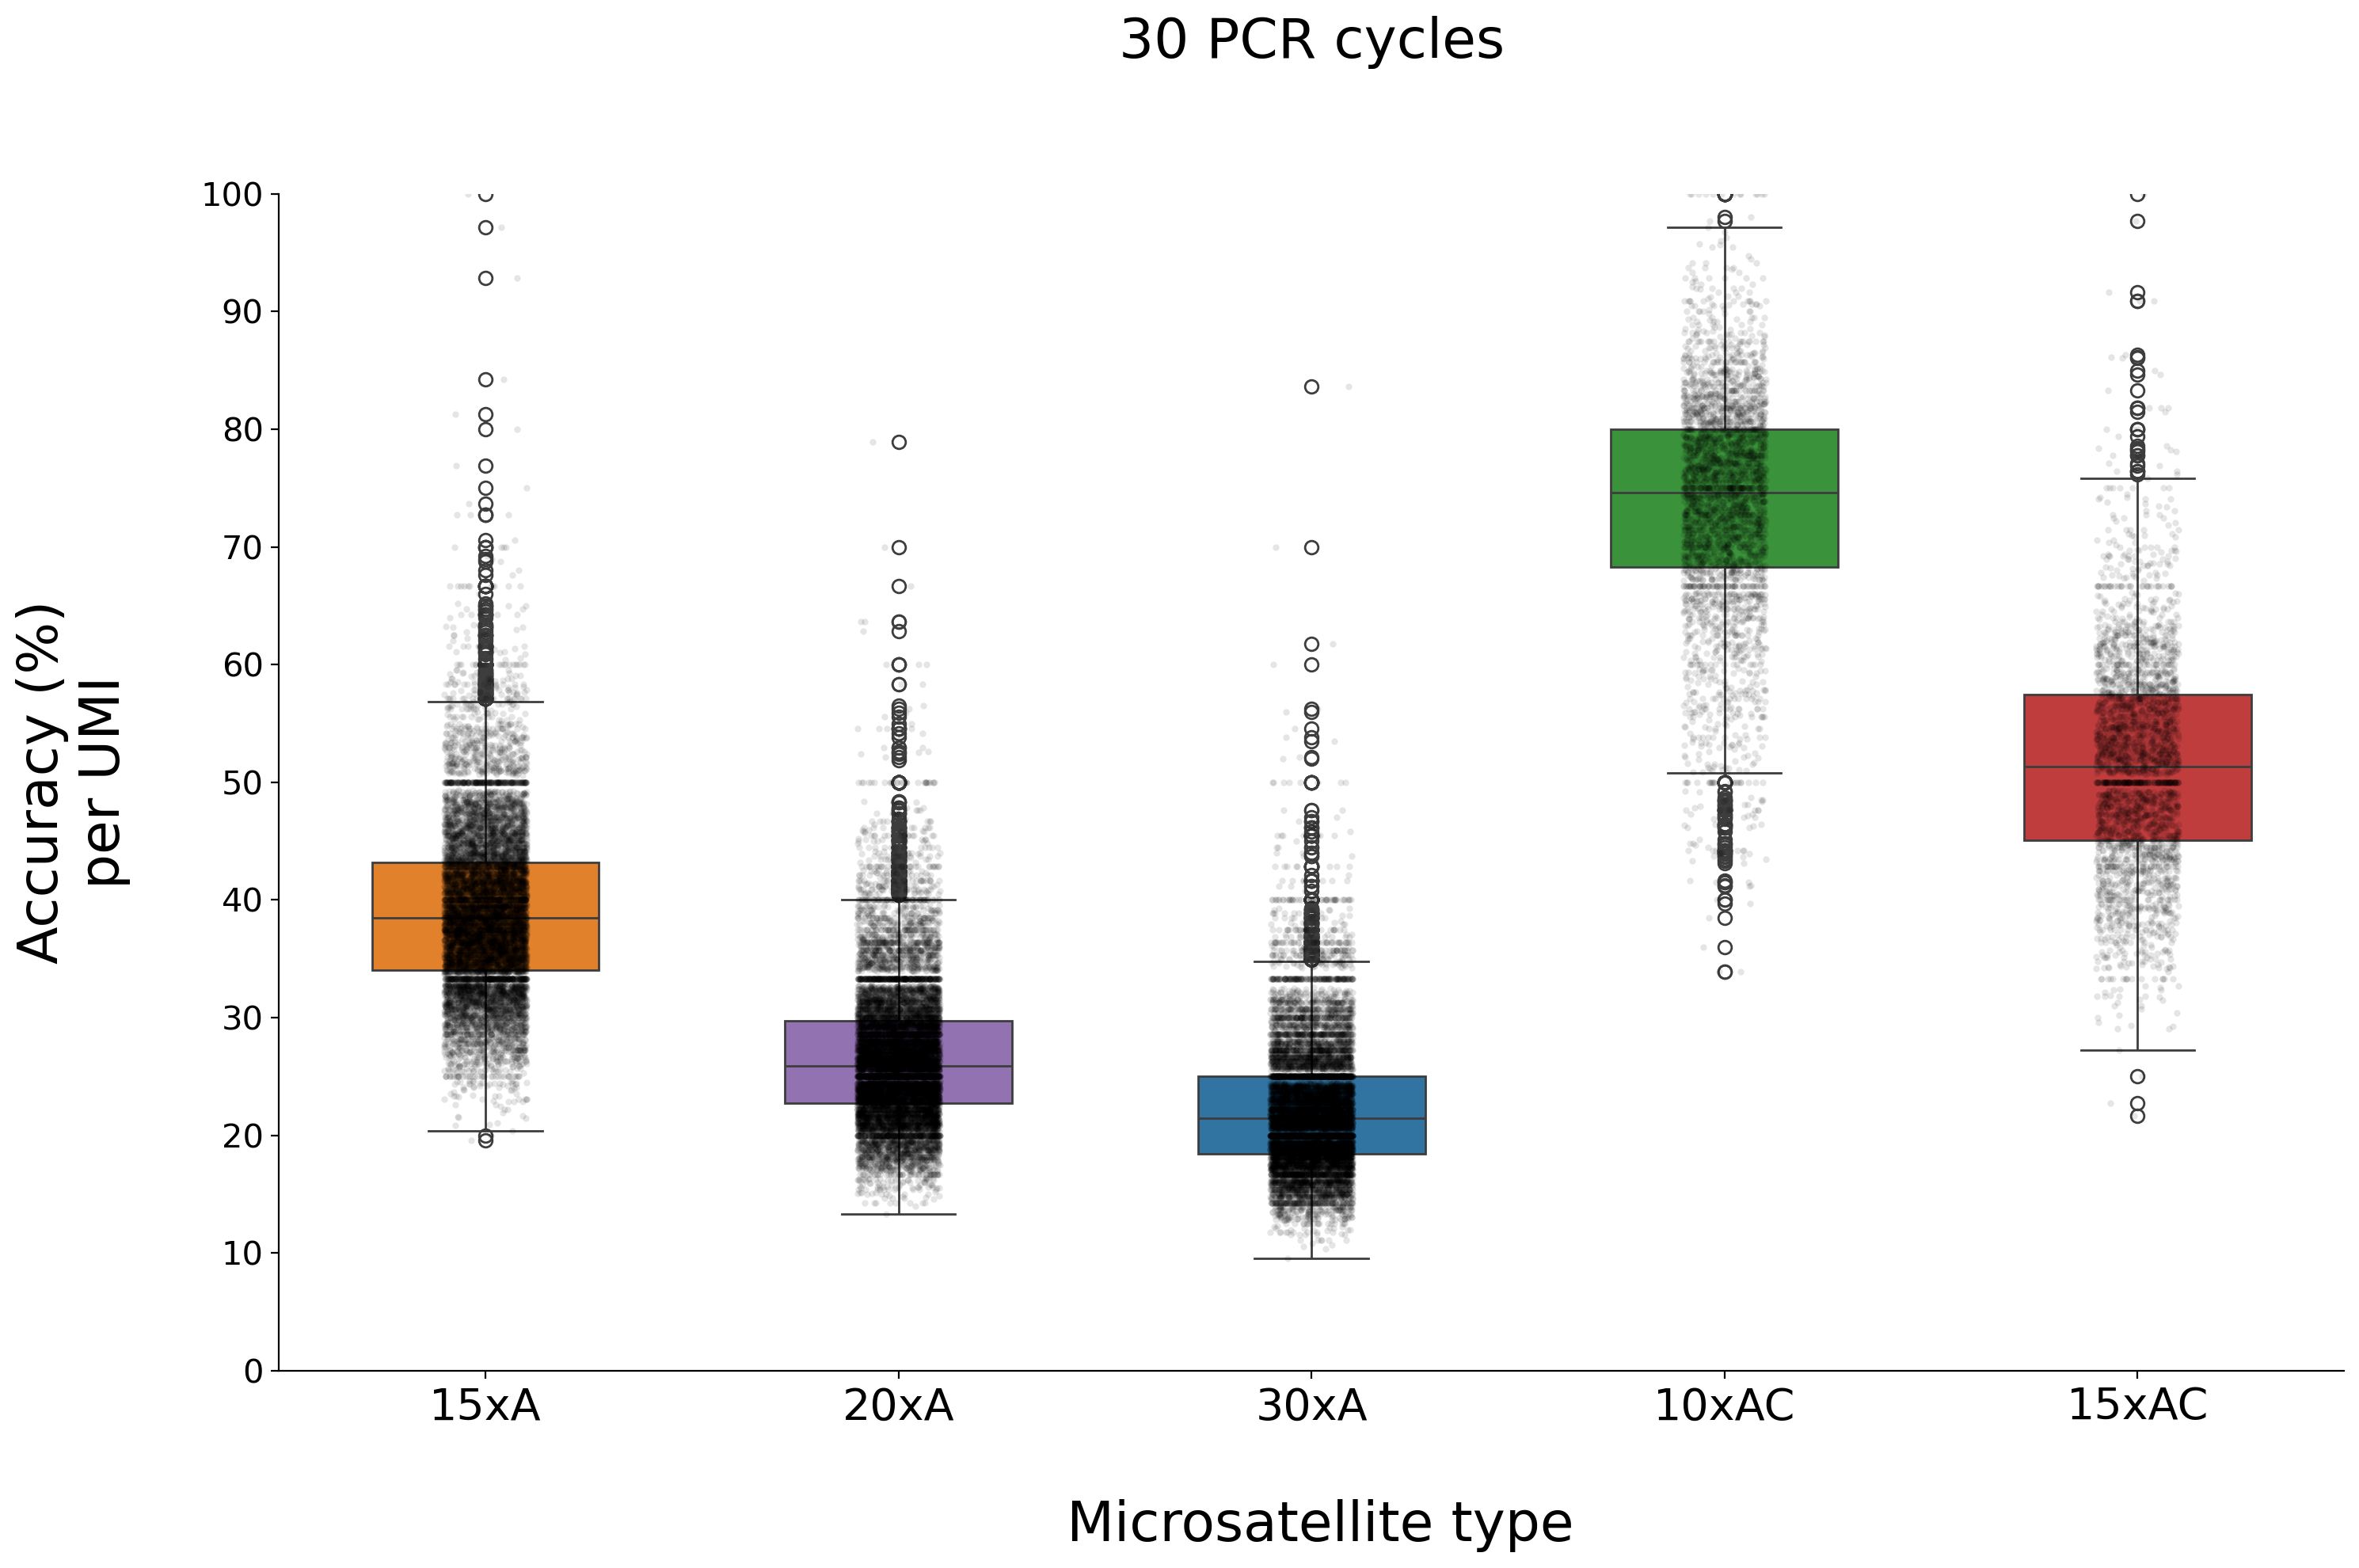

In [55]:
fig, ax = plt.subplots(figsize=(15,10), dpi=200)

sns.boxplot(x='lib_name', y='umi_accuracy', data=umi_acc_df_30, order=['15xA', '20xA', '30xA', '10xAC', '15xAC']
            , width=0.55, hue='lib_name')
sns.stripplot(x='lib_name', y='umi_accuracy', data=umi_acc_df_30, color='black', size=3, dodge=True,
               order=['15xA', '20xA', '30xA', '10xAC', '15xAC'], alpha=0.1)

ax.set_title('30 PCR cycles\n\n', fontsize=25)
ax.set_xlabel("\n Microsatellite type", fontsize=25)
ax.set_ylabel('Accuracy (%)\nper UMI\n', fontsize=25)
ax.tick_params(axis='both', labelsize=15)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_ylim(0,100)
ax.set_yticks(np.arange(0,101,10))
ax.tick_params(axis='x', which='major', labelsize=20)


plt.tight_layout()
plt.show()

# Plot number of PCR cycles used in RETrace v1 vs v2

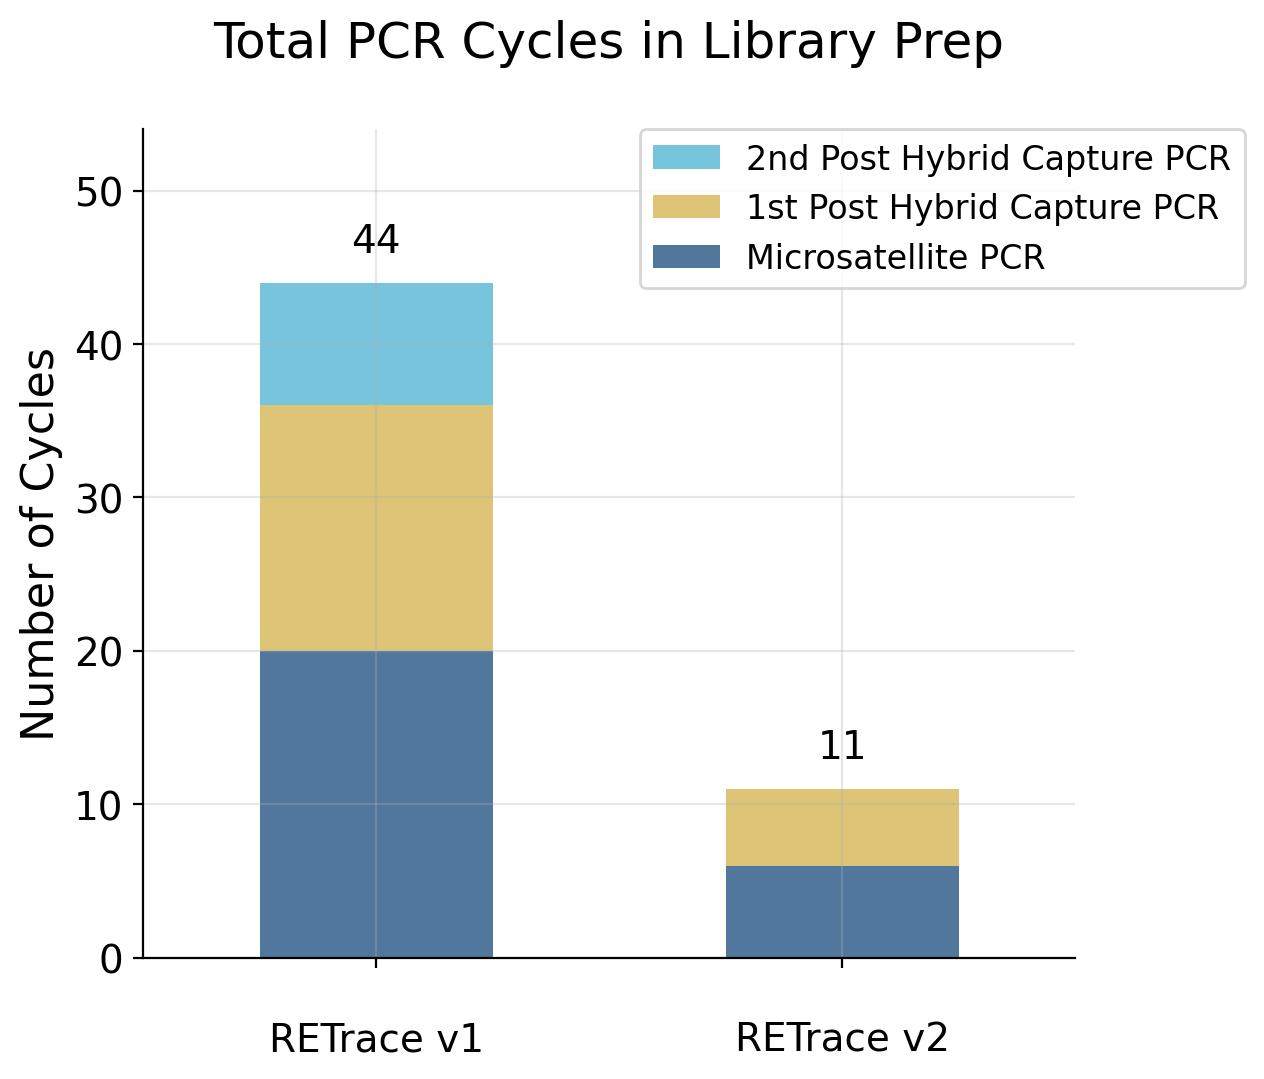

In [ ]:
# Data
data = {
    'RETrace Version': ['\nRETrace v1', '\nRETrace v2'],
    'Microsatellite PCR': [20, 6],
    '1st Post Hybrid Capture PCR': [16, 5],
    '2nd Post Hybrid Capture PCR': [8, 0]
}

df = pd.DataFrame(data)

# Set color palette
colors = ['#4477AA', '#EECC66', '#66CCEE']  # Blue, Yellow, Teal

fig, ax = plt.subplots(figsize=(6.5, 5.5), dpi=200)

# Plot stacked bars
bottom = None
labels = ['Microsatellite PCR', '1st Post Hybrid Capture PCR', '2nd Post Hybrid Capture PCR']
for i, column in enumerate(labels):
    sns.barplot(data=df, x='RETrace Version', y=column, bottom=bottom, 
                color=colors[i], label=column, width=0.5)
    # Update bottom for stacking
    if bottom is None:
        bottom = df[column].copy()
    else:
        bottom += df[column]

# Add total cycle counts as text labels
totals = df[['Microsatellite PCR', '1st Post Hybrid Capture PCR', '2nd Post Hybrid Capture PCR']].sum(axis=1)
for i, total in enumerate(totals):
    ax.text(i, total + 2, f'{int(total)}', ha='center', fontsize=14)

# Customize the plot
ax.set_title('Total PCR Cycles in Library Prep\n', fontsize=18)
ax.set_ylabel('Number of Cycles', fontsize=16)
ax.set_xlabel('', fontsize=0)  
ax.set_ylim(0, 54)
#ax.set_yticks(np.arange(0,55,5))
ax.tick_params(axis='both', labelsize=14)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(True, alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='upper right', fontsize=12, bbox_to_anchor=(1.2, 1.02))

plt.tight_layout()
plt.savefig('PCRcycles_Stacked_Barplot.pdf')
plt.show()